<a href="https://colab.research.google.com/github/kyungeunvoyage/NailFoldExp/blob/Ipynb/(Analysis)Force_Discrimination.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 스타일 설정
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (15, 6)

In [2]:
# 1. 데이터 로드 로직 (요청하신 부분 반영)
file_names = ['P2_Exp2_ForceDiscrimination.csv'] # 확장자 .csv 확인 필요
data_list = []

for file in file_names:
    try:
        temp_df = pd.read_csv(file)
        data_list.append(temp_df)
    except FileNotFoundError:
        print(f"파일을 찾을 수 없습니다: {file}")

# 불러온 데이터가 있을 경우 하나로 병합
if data_list:
    df = pd.concat(data_list, ignore_index=True)
    print(f"총 {len(data_list)}개의 파일을 로드했습니다. 전체 데이터 행 수: {len(df)}")
else:
    print("로드된 데이터가 없습니다.")

총 1개의 파일을 로드했습니다. 전체 데이터 행 수: 36


In [3]:
# 2. 데이터 전처리
def clean_force(x):
    if isinstance(x, str):
        return float(x.replace('g', ''))
    return x

df['RefVal'] = df['Reference'].apply(clean_force)
df['CompVal'] = df['Comparison'].apply(clean_force)
df['WeberRatio'] = (df['CompVal'] - df['RefVal']) / df['RefVal'] # (ΔF / F)
# IsCorrect가 문자열 'true'/'false'일 경우를 대비해 불리언/정수형 변환
df['IsCorrect'] = df['IsCorrect'].map({'true': 1, 'false': 0, True: 1, False: 0})

/tmp/ipykernel_311/3810900702.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Condition', y='IsCorrect', palette='muted', capsize=.1)


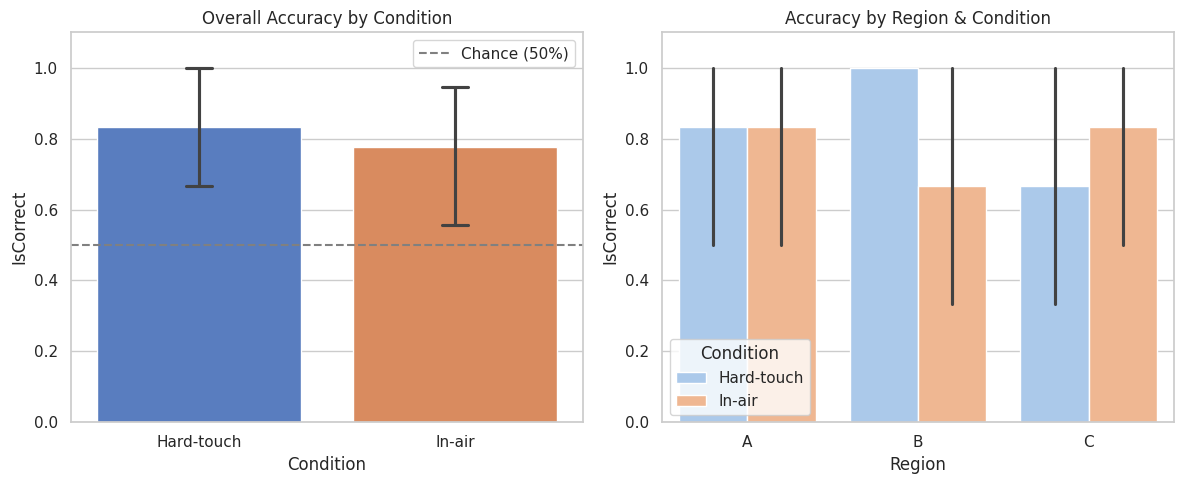

In [4]:
# 3. 주요 지표 시각화 (Accuracy)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))

# (왼쪽) 조건별 정확도
plt.subplot(1, 2, 1)
sns.barplot(data=df, x='Condition', y='IsCorrect', palette='muted', capsize=.1)
plt.axhline(0.5, ls='--', color='gray', label='Chance (50%)')
plt.title('Overall Accuracy by Condition')
plt.ylim(0, 1.1)
plt.legend()

# (오른쪽) 구역(Region) 및 조건별 정확도
plt.subplot(1, 2, 2)
sns.barplot(data=df, x='Region', y='IsCorrect', hue='Condition', order=['A', 'B', 'C'], palette='pastel')
plt.title('Accuracy by Region & Condition')
plt.ylim(0, 1.1)

plt.tight_layout()
plt.show()

/tmp/ipykernel_311/576967448.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='Condition', y='IsCorrect',


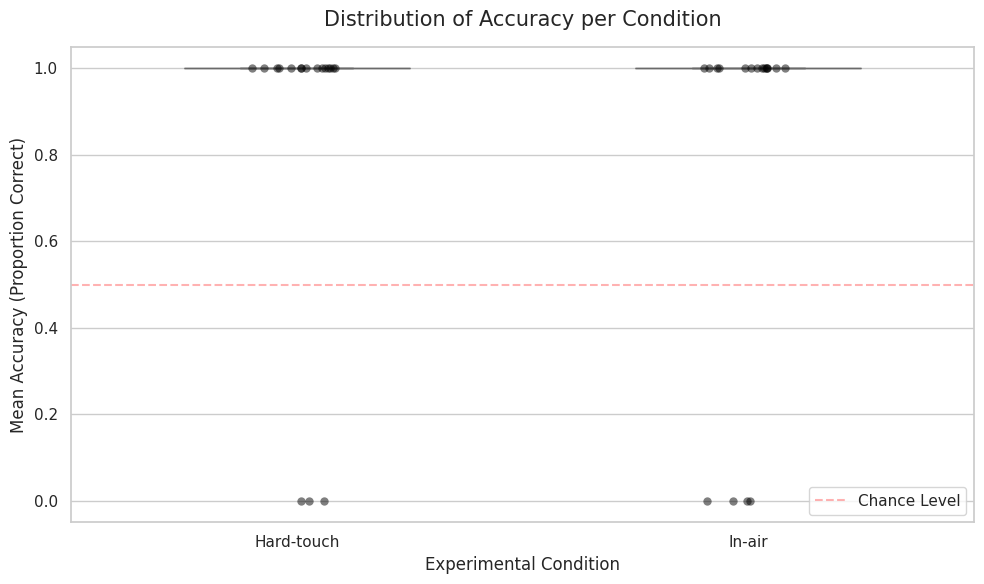

In [6]:
# --- New Analysis Cell: Boxplot with Overlaid Scatter ---
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 시각화를 위한 데이터 그룹화
# 원본 데이터(0, 1)는 이진형이므로, '구역(Region)'과 '자극 쌍(WeberRatio)'별
# 평균 정답률을 계산하여 분포의 '포인트'들을 생성합니다.
plot_data = df.groupby(['Condition', 'Region', 'WeberRatio'])['IsCorrect'].mean().reset_index()

plt.figure(figsize=(10, 6))

# 2. Boxplot 그리기 (분포의 사분위수 표시)
# showfliers=False로 설정하여 중복되는 아웃라이어 점을 숨기고 scatter로 대체합니다.
sns.boxplot(data=plot_data, x='Condition', y='IsCorrect',
            palette='Set3', width=0.5, showfliers=False)

# 3. Scatter plot(Stripplot) 겹치기 (모든 데이터 포인트 표시)
# jitter=True를 주어 점들이 겹치지 않게 옆으로 살짝 퍼뜨립니다.
sns.stripplot(data=plot_data, x='Condition', y='IsCorrect',
              color='black', size=6, jitter=True, alpha=0.5)

# 4. 그래프 디테일 설정
plt.title('Distribution of Accuracy per Condition', fontsize=15, pad=15)
plt.ylabel('Mean Accuracy (Proportion Correct)', fontsize=12)
plt.xlabel('Experimental Condition', fontsize=12)
plt.ylim(-0.05, 1.05) # 정답률 범위 고정
plt.axhline(0.5, ls='--', color='red', alpha=0.3, label='Chance Level') # 무작위 정답 확률 라인
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\D'
<>:9: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_311/2326878783.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Weber Ratio ($\Delta F / F_{ref}$)')


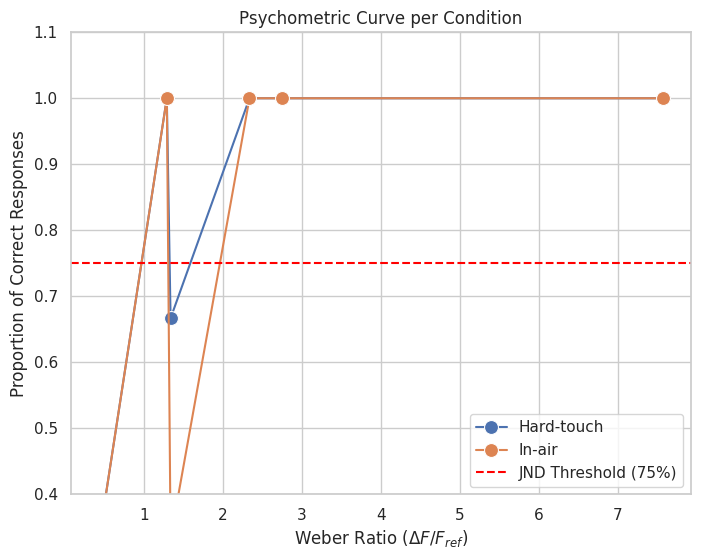


[분석 결과 요약]
 - Hard-touch 조건의 Weber Fraction (K): 약 0.964
 - In-air 조건의 Weber Fraction (K): 약 0.964


In [5]:
# 4. Psychometric Curve (Weber Fraction 추정용)
# Weber Ratio(ΔF/F)에 따른 정답률 계산
psychometric_data = df.groupby(['Condition', 'WeberRatio'])['IsCorrect'].mean().reset_index()

plt.figure(figsize=(8, 6))
sns.lineplot(data=psychometric_data, x='WeberRatio', y='IsCorrect', hue='Condition', marker='o', markersize=10)
plt.axhline(0.75, color='red', linestyle='--', label='JND Threshold (75%)')
plt.title('Psychometric Curve per Condition')
plt.xlabel('Weber Ratio ($\Delta F / F_{ref}$)')
plt.ylabel('Proportion of Correct Responses')
plt.ylim(0.4, 1.1)
plt.legend()
plt.show()

# 5. Weber Fraction (K) 결과 출력
print("\n[분석 결과 요약]")
for cond in df['Condition'].unique():
    cond_df = psychometric_data[psychometric_data['Condition'] == cond].sort_values('WeberRatio')
    if len(cond_df) >= 2:
        # 선형 보간을 통한 75% 정답률 지점(Weber Fraction) 계산
        k_est = np.interp(0.75, cond_df['IsCorrect'], cond_df['WeberRatio'])
        print(f" - {cond} 조건의 Weber Fraction (K): 약 {k_est:.3f}")
    else:
        print(f" - {cond} 조건: 데이터 포인트가 부족하여 K 추정 불가")